In [4]:
# Ячейка 1: Импорт библиотек и загрузка данных
import os
import zipfile
import requests
import matplotlib.pyplot as plt
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
import shutil

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

# Устанавливаем gdown для скачивания с Google Drive
!pip install gdown -q
import gdown

# ID файла из вашей ссылки
FILE_ID = "1H0EGwT8SmgdOYcl1EFTT619wl9Nc17_L"

def download_dataset():
    """Скачивает и распаковывает датасет с Google Drive"""

    # Скачиваем, если ещё не скачали
    zip_path = '/content/up+low.zip'  # Используем правильное имя файла

    if not os.path.exists(zip_path):
        print("Скачиваем датасет с Google Drive...")

        # Способ 1: Прямая ссылка через gdown с confirm
        url = f"https://drive.google.com/uc?id={FILE_ID}&export=download&confirm=t"

        try:
            # Пробуем скачать через gdown с confirm
            gdown.download(url, zip_path, quiet=False, fuzzy=True)
        except:
            # Если не работает, используем requests
            print("Пробуем альтернативный способ...")
            session = requests.Session()
            response = session.get(f"https://drive.google.com/uc?id={FILE_ID}&export=download", stream=True)

            # Получаем confirm-токен
            for key, value in response.cookies.items():
                if key.startswith('download_warning'):
                    confirm_token = value
                    response = session.get(f"https://drive.google.com/uc?id={FILE_ID}&export=download&confirm={confirm_token}", stream=True)
                    break

            # Сохраняем файл
            with open(zip_path, 'wb') as f:
                for chunk in response.iter_content(chunk_size=32768):
                    if chunk:
                        f.write(chunk)

        print("Скачивание завершено!")

    # Проверяем, что файл действительно ZIP
    if not zipfile.is_zipfile(zip_path):
        print(" Ошибка: скачанный файл не является ZIP-архивом!")
        print("Проверьте ссылку и права доступа к файлу.")
        # Показываем первые 100 байт для диагностики
        with open(zip_path, 'rb') as f:
            content = f.read(200)
            print(f"Первые 200 байт файла: {content[:100]}")
        return None, None

    # Распаковываем
    extract_path = '/content/digits'
    if os.path.exists(extract_path):
        shutil.rmtree(extract_path)  # Очищаем старую папку

    print("Распаковываем...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content')
    print("Распаковка завершена!")

    # Определяем пути (внутри ZIP может быть папка up+low)
    if os.path.exists('/content/up+low/images'):
        IMAGES_PATH = '/content/up+low/images'
        LABELS_PATH = '/content/up+low/labels'
    else:
        IMAGES_PATH = '/content/digits/images'
        LABELS_PATH = '/content/digits/labels'

    return IMAGES_PATH, LABELS_PATH

# Загружаем данные
IMAGES_PATH, LABELS_PATH = download_dataset()

if IMAGES_PATH:
    print(f"\n Путь к изображениям: {IMAGES_PATH}")
    print(f"Путь к аннотациям: {LABELS_PATH}")
    print(f"Изображения: {len(os.listdir(IMAGES_PATH))}")
    print(f"Аннотации: {len(os.listdir(LABELS_PATH))}")
else:
    print("Не удалось загрузить датасет")

Распаковываем...
Распаковка завершена!

 Путь к изображениям: /content/up+low/images
Путь к аннотациям: /content/up+low/labels
Изображения: 17445
Аннотации: 17445


In [5]:
# Ячейка 2: Разделение на обучающую (70%) и тестовую (30%) выборки
# С подвыборкой для быстрого обучения на CPU


USE_N_FILES = 1000  # 1000 изображений для быстрого обучения (было 17000)


# Получаем список всех файлов
images_files = [f.replace('.png', '') for f in os.listdir(IMAGES_PATH) if f.endswith('.png')]
labels_files = [f.replace('.txt', '') for f in os.listdir(LABELS_PATH) if f.endswith('.txt')]

# Находим общие файлы
common_files = sorted(set(images_files) & set(labels_files))
print(f"Всего файлов: {len(common_files)}")

# Берём только первые N файлов
if USE_N_FILES:
    common_files = common_files[:USE_N_FILES]
    print(f"Используем подвыборку: {len(common_files)} файлов")


# Разделение
train_files, test_files = train_test_split(
    common_files,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

print(f"\nОбучающая выборка: {len(train_files)} ({len(train_files)/len(common_files)*100:.1f}%)")
print(f"Тестовая выборка: {len(test_files)} ({len(test_files)/len(common_files)*100:.1f}%)")

# Сохраняем списки
with open('/content/train_files.txt', 'w') as f:
    for file in train_files:
        f.write(f"{file}\n")

with open('/content/test_files.txt', 'w') as f:
    for file in test_files:
        f.write(f"{file}\n")

Всего файлов: 17445
Используем подвыборку: 1000 файлов

Обучающая выборка: 700 (70.0%)
Тестовая выборка: 300 (30.0%)


In [6]:
# Ячейка 3 (ИСПРАВЛЕННАЯ): Класс Dataset для загрузки данных

class WagonDataset(Dataset):
    """Dataset для загрузки изображений и аннотаций в формате YOLO"""

    def __init__(self, images_dir, labels_dir, file_list, transform=None):
        """
        Args:
            images_dir: путь к папке с изображениями
            labels_dir: путь к папке с аннотациями
            file_list: список имен файлов (без расширения)
            transform: аугментации
        """
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.file_list = file_list
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_name = self.file_list[idx]

        # Загрузка изображения
        img_path = os.path.join(self.images_dir, f"{file_name}.png")
        image = cv2.imread(img_path)
        if image is None:
            print(f"Warning: Could not load image {img_path}")
            # Возвращаем пустое изображение
            image = np.zeros((640, 640, 3), dtype=np.uint8)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Загрузка аннотаций
        label_path = os.path.join(self.labels_dir, f"{file_name}.txt")
        boxes = []
        labels = []

        if os.path.exists(label_path):
            h, w = image.shape[:2]
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        class_id = int(parts[0])
                        cx = float(parts[1]) * w
                        cy = float(parts[2]) * h
                        bw = float(parts[3]) * w
                        bh = float(parts[4]) * h

                        # Преобразуем в формат [x_min, y_min, x_max, y_max]
                        x_min = cx - bw/2
                        y_min = cy - bh/2
                        x_max = cx + bw/2
                        y_max = cy + bh/2

                        boxes.append([x_min, y_min, x_max, y_max])
                        labels.append(class_id)

        boxes = np.array(boxes, dtype=np.float32) if boxes else np.zeros((0, 4), dtype=np.float32)
        labels = np.array(labels, dtype=np.int64) if labels else np.zeros((0,), dtype=np.int64)

        # Применяем аугментации
        if self.transform:
            transformed = self.transform(image=image, bboxes=boxes, labels=labels)
            image = transformed['image']
            # ИСПРАВЛЕНИЕ: проверяем длину списка, а не булево значение массива
            boxes = np.array(transformed['bboxes']) if len(transformed['bboxes']) > 0 else np.zeros((0, 4), dtype=np.float32)
            labels = np.array(transformed['labels']) if len(transformed['labels']) > 0 else np.zeros((0,), dtype=np.int64)

        # Преобразуем в тензоры
        if not isinstance(image, torch.Tensor):
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0

        boxes = torch.from_numpy(boxes).float()
        labels = torch.from_numpy(labels).long()

        # Целевой формат для Faster R-CNN
        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([idx])
        }

        return image, target


def collate_fn(batch):
    """Функция для объединения батча"""
    return tuple(zip(*batch))

In [7]:
# Ячейка 4: Определение аугментаций и создание загрузчиков данных

# Аугментации для обучения
train_transform = A.Compose([
    A.Resize(height=640, width=640),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))

# Аугментации для валидации/теста (только resize и нормализация)
val_transform = A.Compose([
    A.Resize(height=640, width=640),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))

# Создаем датасеты
train_dataset = WagonDataset(
    images_dir=IMAGES_PATH,
    labels_dir=LABELS_PATH,
    file_list=train_files,
    transform=train_transform
)

test_dataset = WagonDataset(
    images_dir=IMAGES_PATH,
    labels_dir=LABELS_PATH,
    file_list=test_files,
    transform=val_transform
)

# Создаем DataLoader
batch_size = 2  # было 4
num_workers = 0  # было 2 (на CPU лучше 0)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    collate_fn=collate_fn
)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 350
Test batches: 150


In [8]:
# Ячейка 5: Создание модели (СТАБИЛЬНАЯ ВЕРСИЯ)

from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn

def get_model(num_classes=10):
    """
    Создает модель Faster R-CNN с MobileNetV3 backbone.
    """
    model = fasterrcnn_mobilenet_v3_large_fpn(
        pretrained=False,
        num_classes=num_classes + 1
    )
    return model

# Определяем устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

# Создаем модель
model = get_model(num_classes=10).to(device)

print(f"Количество параметров: {sum(p.numel() for p in model.parameters()):,}")

# Используем AdamW (более стабильный, чем SGD) и меньший learning rate
optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0001,  # значительно уменьшаем learning rate
    weight_decay=0.0005
)

# Добавляем scheduler для плавного уменьшения lr
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# Создаем папку для сохранения модели
os.makedirs('/content/models', exist_ok=True)

print("Модель создана!")
print(f"Learning rate: {optimizer.param_groups[0]['lr']}")

Используется устройство: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 58.1MB/s]


Количество параметров: 18,976,354
Модель создана!
Learning rate: 0.0001


In [9]:
# Ячейка 6 (исправленная): Функция для расчета mAP

from torchvision.ops import box_iou

def calculate_map(model, data_loader, device, iou_threshold=0.5):
    """
    Рассчитывает mAP на тестовой выборке
    """
    model.eval()
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for images, targets in data_loader:
            images = [img.to(device) for img in images]

            # Получаем предсказания
            outputs = model(images)

            # Сохраняем предсказания и истинные боксы
            for output, target in zip(outputs, targets):
                pred_boxes = output['boxes'].cpu()
                pred_scores = output['scores'].cpu()
                pred_labels = output['labels'].cpu()

                # Берем только предсказания с высоким confidence
                keep = pred_scores > 0.5
                pred_boxes = pred_boxes[keep]
                pred_scores = pred_scores[keep]
                pred_labels = pred_labels[keep]

                all_predictions.append({
                    'boxes': pred_boxes,
                    'scores': pred_scores,
                    'labels': pred_labels
                })

                all_targets.append({
                    'boxes': target['boxes'].cpu(),
                    'labels': target['labels'].cpu()
                })

    # Расчет AP для каждого класса
    num_classes = 10
    aps = []

    for class_id in range(num_classes):
        tp = []
        fp = []
        scores = []

        # Собираем предсказания для текущего класса
        for pred, target in zip(all_predictions, all_targets):
            # Предсказания текущего класса (labels: 1-10, где 1-10 соответствуют цифрам 0-9)
            class_pred_mask = pred['labels'] == (class_id + 1)
            class_pred_boxes = pred['boxes'][class_pred_mask]
            class_pred_scores = pred['scores'][class_pred_mask]

            # Истинные боксы текущего класса
            class_target_mask = target['labels'] == class_id
            class_target_boxes = target['boxes'][class_target_mask]

            if len(class_target_boxes) == 0 and len(class_pred_boxes) == 0:
                continue

            if len(class_target_boxes) == 0:
                # Ложные срабатывания
                for _ in range(len(class_pred_boxes)):
                    tp.append(0)
                    fp.append(1)
                    # Используем score из предсказания
                    scores.append(class_pred_scores[_])
                continue

            if len(class_pred_boxes) == 0:
                continue

            # Сортируем предсказания по уверенности
            sorted_idx = class_pred_scores.argsort(descending=True)
            class_pred_boxes = class_pred_boxes[sorted_idx]
            class_pred_scores = class_pred_scores[sorted_idx]

            # Отмечаем, какие истинные боксы уже использованы
            target_used = torch.zeros(len(class_target_boxes), dtype=torch.bool)

            for i, pred_box in enumerate(class_pred_boxes):
                # Вычисляем IoU со всеми истинными боксами
                ious = box_iou(pred_box.unsqueeze(0), class_target_boxes)[0]
                max_iou, max_idx = ious.max(0)

                if max_iou >= iou_threshold and not target_used[max_idx]:
                    tp.append(1)
                    fp.append(0)
                    target_used[max_idx] = True
                else:
                    tp.append(0)
                    fp.append(1)
                # ИСПРАВЛЕНИЕ: используем i вместо неопределенного idx
                scores.append(class_pred_scores[i].item())

        if len(tp) == 0:
            aps.append(0.0)
            continue

        # Преобразуем в тензоры
        tp = torch.tensor(tp, dtype=torch.float32)
        fp = torch.tensor(fp, dtype=torch.float32)
        scores = torch.tensor(scores, dtype=torch.float32)

        # Сортируем по убыванию scores
        sorted_idx = scores.argsort(descending=True)
        tp = tp[sorted_idx]
        fp = fp[sorted_idx]

        # Кумулятивные суммы
        tp_cumsum = tp.cumsum(0)
        fp_cumsum = fp.cumsum(0)

        # Precision и Recall
        precision = tp_cumsum / (tp_cumsum + fp_cumsum + 1e-10)  # добавляем эпсилон для стабильности
        recall = tp_cumsum / len(class_target_boxes)

        # Добавляем начальные точки
        precision = torch.cat([torch.tensor([1.0]), precision])
        recall = torch.cat([torch.tensor([0.0]), recall])

        # Интерполяция AP по 11 точкам
        ap = 0.0
        for t in torch.linspace(0, 1, 11):
            # Находим максимальную precision при recall >= t
            mask = recall >= t
            if mask.any():
                ap += precision[mask].max().item()
            else:
                ap += precision[-1].item()
        ap /= 11

        aps.append(ap)

    return np.mean(aps), aps

In [10]:
# Ячейка 7: Функции обучения и валидации

def train_one_epoch(model, loader, optimizer, device, epoch):
    """
    Обучение одной эпохи
    """
    model.train()
    total_loss = 0
    num_batches = len(loader)

    for batch_idx, (images, targets) in enumerate(loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        losses.backward()
        optimizer.step()

        total_loss += losses.item()

        if batch_idx % 50 == 0:
            print(f"  Batch {batch_idx}/{num_batches}, Loss: {losses.item():.4f}")

    avg_loss = total_loss / num_batches
    print(f"Epoch {epoch} finished, Average Loss: {avg_loss:.4f}")
    return avg_loss


def validate(model, loader, device):
    """
    Валидация модели
    """
    model.train()  # Включаем train режим для получения loss
    total_loss = 0
    num_batches = len(loader)

    with torch.no_grad():
        for images, targets in loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            total_loss += losses.item()

    model.eval()  # Возвращаем в eval режим
    avg_loss = total_loss / num_batches
    return avg_loss

In [11]:
# Ячейка 8: Запуск обучения

num_epochs = 5
best_val_loss = float('inf')
patience_counter = 0
early_stop_patience = 5

print("Начинаем обучение...")
print("="*50)

for epoch in range(1, num_epochs + 1):
    print(f"\nЭпоха {epoch}/{num_epochs}")
    print("-"*30)

    # Обучение
    train_loss = train_one_epoch(model, train_loader, optimizer, device, epoch)

    # Проверка на nan
    if np.isnan(train_loss):
        print("Обнаружен nan loss! Обучение остановлено.")
        print("Попробуйте уменьшить learning rate еще больше.")
        break

    # Валидация
    val_loss = validate(model, test_loader, device)
    print(f"Validation Loss: {val_loss:.4f}")

    # Step scheduler
    scheduler.step()

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '/content/models/best_model.pth')
        print(f"Модель сохранена (loss: {val_loss:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"Без улучшения ({patience_counter}/{early_stop_patience})")

    if patience_counter >= early_stop_patience:
        print(f"Ранняя остановка на эпохе {epoch}")
        break

print("\n" + "="*50)
print("Обучение завершено!")
print(f"Лучший validation loss: {best_val_loss:.4f}")

Начинаем обучение...

Эпоха 1/5
------------------------------
  Batch 0/350, Loss: 3.8978
  Batch 50/350, Loss: 1.8868
  Batch 100/350, Loss: 1.3216
  Batch 150/350, Loss: 1.0617
  Batch 200/350, Loss: 1.1963
  Batch 250/350, Loss: 0.9053
  Batch 300/350, Loss: 0.4291
Epoch 1 finished, Average Loss: 1.2227
Validation Loss: 0.6428
✓ Модель сохранена (loss: 0.6428)

Эпоха 2/5
------------------------------
  Batch 0/350, Loss: 0.5387
  Batch 50/350, Loss: 0.5509
  Batch 100/350, Loss: 0.4671
  Batch 150/350, Loss: 0.6098
  Batch 200/350, Loss: 0.3928
  Batch 250/350, Loss: 0.6978
  Batch 300/350, Loss: 0.9693
Epoch 2 finished, Average Loss: 0.6420
Validation Loss: 0.5739
✓ Модель сохранена (loss: 0.5739)

Эпоха 3/5
------------------------------
  Batch 0/350, Loss: 0.5505
  Batch 50/350, Loss: 0.4325
  Batch 100/350, Loss: 0.7749
  Batch 150/350, Loss: 0.6464
  Batch 200/350, Loss: 0.7799
  Batch 250/350, Loss: 0.4278
  Batch 300/350, Loss: 0.3732
Epoch 3 finished, Average Loss: 0.5701

In [12]:
# Ячейка 9: Оценка модели на тестовой выборке

# Загружаем лучшую модель
model.load_state_dict(torch.load('/content/models/best_model.pth'))

# Рассчитываем mAP
print("Расчет mAP на тестовой выборке...")
mAP, per_class_aps = calculate_map(model, test_loader, device)

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ ОЦЕНКИ")
print("="*50)
print(f"mAP@0.5: {mAP:.4f}")

print("\nAP по классам:")
for class_id, ap in enumerate(per_class_aps):
    print(f"  Класс {class_id}: {ap:.4f}")

Расчет mAP на тестовой выборке...

РЕЗУЛЬТАТЫ ОЦЕНКИ
mAP@0.5: 0.0848

AP по классам:
  Класс 0: 0.0909
  Класс 1: 0.0909
  Класс 2: 0.0909
  Класс 3: 0.0909
  Класс 4: 0.0937
  Класс 5: 0.1000
  Класс 6: 0.0909
  Класс 7: 0.0909
  Класс 8: 0.1090
  Класс 9: 0.0000


In [13]:
# Ячейка 9.5: Загрузка модели для визуализации

# Создаем модель с той же архитектурой
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn

def get_model(num_classes=10):
    model = fasterrcnn_mobilenet_v3_large_fpn(
        pretrained=False,
        num_classes=num_classes + 1
    )
    return model

# Определяем устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

# Создаем модель
model = get_model(num_classes=10).to(device)

# Загружаем сохраненные веса (если есть)
model_path = '/content/models/best_model.pth'
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    print(f"Модель загружена из {model_path}")
else:
    print(f"Внимание: файл {model_path} не найден! Используется неподготовленная модель.")

model.eval()
print("Модель готова к визуализации")

Используется устройство: cuda
Модель загружена из /content/models/best_model.pth
Модель готова к визуализации


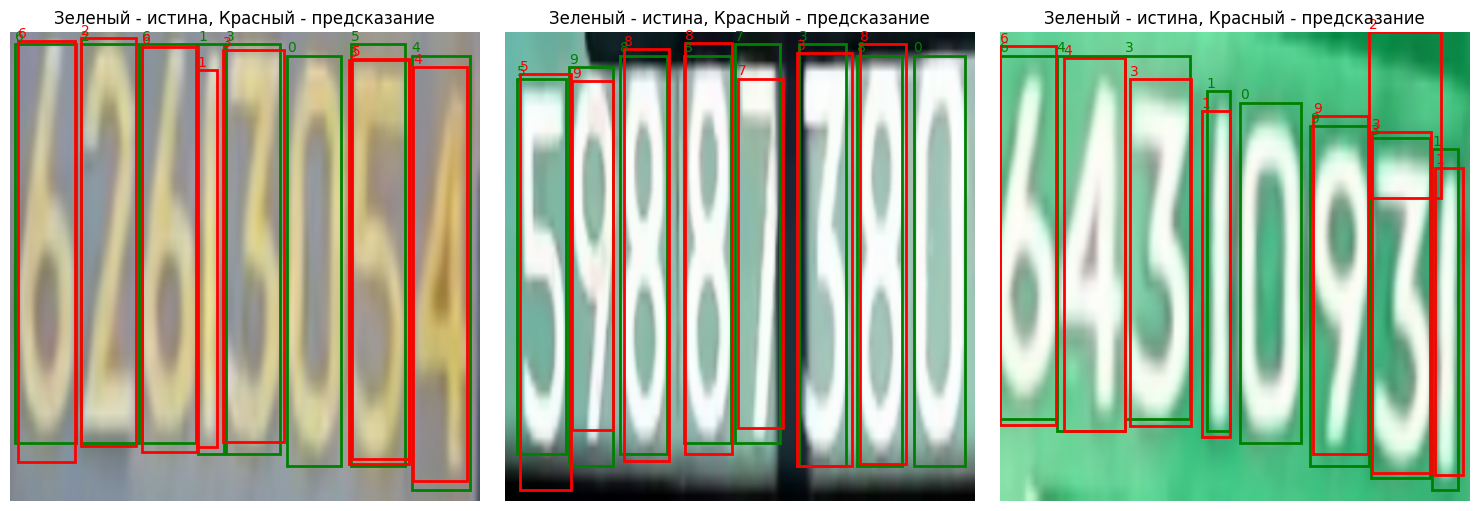

In [14]:
# Ячейка 10: Визуализация предсказаний (опционально)

def visualize_predictions(model, dataset, device, num_samples=3):
    """Визуализация предсказаний модели"""
    model.eval()

    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))

    for i in range(min(num_samples, len(dataset))):
        image, target = dataset[i]
        image_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():
            predictions = model(image_tensor)[0]

        # Денормализуем изображение
        img = image.permute(1, 2, 0).cpu().numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = img * std + mean
        img = np.clip(img, 0, 1)

        axes[i].imshow(img)

        # Рисуем истинные боксы (зеленые)
        for box, label in zip(target['boxes'], target['labels']):
            x1, y1, x2, y2 = box
            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1,
                                fill=False, edgecolor='green', linewidth=2)
            axes[i].add_patch(rect)
            axes[i].text(x1, y1-5, str(int(label)), color='green', fontsize=10)

        # Рисуем предсказанные боксы (красные)
        for box, score, label in zip(predictions['boxes'][:10],
                                      predictions['scores'][:10],
                                      predictions['labels'][:10]):
            if score > 0.5:
                x1, y1, x2, y2 = box.cpu().numpy()
                rect = plt.Rectangle((x1, y1), x2-x1, y2-y1,
                                    fill=False, edgecolor='red', linewidth=2)
                axes[i].add_patch(rect)
                axes[i].text(x1, y1-5, f"{int(label)}", color='red', fontsize=10)

        axes[i].set_title(f"Зеленый - истина, Красный - предсказание")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Визуализируем
visualize_predictions(model, test_dataset, device)